**PARTE PREVIA**

A continuaci?n realizaremos un estudio sobre los datasets subidos para realizar el trabajo pr?ctico (en adelante TP). En este notebook nos concentramos en el dataset de Facebook y en el archivo de posiciones asociado (`fb_positions.pkl`).

El objetivo es caracterizar la red, analizar sus m?tricas principales, visualizar su estructura, estudiar centralidades, comunidades, robustez y compararla con una red aleatoria equivalente.

**INFORMACI?N SOBRE LOS DATOS**

*  C. elegans: Una red dirigida y pesada que representa la red de conexiones neuronales en el organismo Caenorhabditis elegans.

*  Facebook: Una red no dirigida y no pesada de c?rculos de Facebook. Cada nodo es un perfil de Facebook y un enlace significa que los perfiles son amigos en Facebook. Contiene 4039 nodos y 88234 enlaces.

*  Email-EU: Una red no dirigida y no pesada de contactos v?a e-mail en una instituci?n europea de investigaci?n.

*  Aeropuertos: Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos y los enlaces representan vuelos.

*  CONICET: Una red no dirigida y no pesada. Cada nodo es un autor y los enlaces representan colaboraciones acad?micas.

**SET DE INDICADORES PARA REALIZAR EL AN?LISIS E INSPECCI?N DEL DATASET**

*  Caracter?sticas de la red: es dirigida?, es pesada?, es conectada?
*  An?lisis de componente gigante: borrando autoenlaces, analizamos su conexi?n.
*  Visualizaci?n espacial/topol?gica usando el archivo `fb_positions.pkl`.
*  Grados de nodo.
*  Coeficiente de clustering.
*  Coeficiente de transitividad.
*  Coeficiente de asortatividad.
*  Distancias m?nimas medias.
*  Centralidades: grado, intermediaci?n y PageRank.
*  Detecci?n de comunidades.
*  Robustez frente a eliminaci?n aleatoria y ataques dirigidos.
*  Comparaci?n con una red aleatoria de Erd?s-R?nyi.

**CARGANDO LIBRER?AS Y ARCHIVOS**

In [1]:
# Instalar dependencias necesarias antes de ejecutar el an?lisis.
# En Colab o Jupyter, correr esta celda una vez si aparece ModuleNotFoundError.
%pip install -q matplotlib numpy pandas scipy networkx python-louvain


In [2]:
import os
import sys
import pickle
import subprocess
import importlib.util
from pathlib import Path

required_packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "networkx": "networkx",
    "community": "python-louvain",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Instalando dependencias faltantes:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import community.community_louvain as cl

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

In [3]:
# Esta celda permite correr el notebook tanto en Colab/Drive como en local.
# Si no encuentra los datos, descarga datasets-tp1.zip y lo descomprime autom?ticamente.
import zipfile
import urllib.request

DATASET_URL = "https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7&st=09rgvayp&dl=1"
ZIP_PATH = Path("datasets-tp1.zip")

required_files = ["facebook.txt", "fb_positions.pkl"]


def has_facebook_files(directory):
    return directory.exists() and all((directory / file_name).exists() for file_name in required_files)


def find_facebook_data_dir():
    candidate_dirs = [
        Path("datasets-tp1"),
        Path("../datasets-tp1"),
        Path("."),
        Path("Insumos"),
        Path("insumos"),
        Path("../Insumos"),
        Path("../insumos"),
        Path("Insumos/datasets-tp1"),
        Path("insumos/datasets-tp1"),
        Path("../Insumos/datasets-tp1"),
        Path("../insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/Insumos"),
        Path("/content/drive/MyDrive/Insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/insumos"),
        Path("/content/drive/MyDrive/insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/TP1/datasets-tp1"),
    ]

    for candidate in candidate_dirs:
        if has_facebook_files(candidate):
            return candidate

    return None


def download_and_extract_datasets():
    print("No encontr? los datos de Facebook. Descargando datasets-tp1.zip...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Descomprimiendo datasets-tp1.zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(Path("."))

    data_dir = find_facebook_data_dir()
    if data_dir is None:
        raise FileNotFoundError(
            "Descargu? el zip, pero no encontr? facebook.txt y fb_positions.pkl. "
            "Revisar la estructura del archivo descomprimido."
        )
    return data_dir


DATA_DIR = find_facebook_data_dir()

if DATA_DIR is None:
    DATA_DIR = download_and_extract_datasets()

FACEBOOK_EDGES = DATA_DIR / "facebook.txt"
FACEBOOK_POSITIONS = DATA_DIR / "fb_positions.pkl"

print("Directorio de datos:", DATA_DIR.resolve())
print("Archivo de aristas:", FACEBOOK_EDGES)
print("Archivo de posiciones:", FACEBOOK_POSITIONS)

No encontr? los datos de Facebook. Descargando datasets-tp1.zip...
Descomprimiendo datasets-tp1.zip...
Directorio de datos: /content
Archivo de aristas: facebook.txt
Archivo de posiciones: fb_positions.pkl


## Facebook

Realizamos la carga del dataset de Facebook. El archivo `facebook.txt` contiene una lista de enlaces, con un par de nodos por l?nea. Como la red representa amistades, construimos un grafo no dirigido y no pesado.

In [4]:
# Cargar edgelist de Facebook
G = nx.read_edgelist(FACEBOOK_EDGES, nodetype=int, create_using=nx.Graph())

print(G)
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())
print("Autoenlaces:", nx.number_of_selfloops(G))

Graph with 4039 nodes and 88234 edges
Nodos: 4039
Aristas: 88234
Autoenlaces: 0


In [5]:
# Cargar posiciones precalculadas para visualizar la red
with open(FACEBOOK_POSITIONS, "rb") as f:
    pos = pickle.load(f)

# Nos quedamos con posiciones de nodos presentes en el grafo
pos = {int(n): tuple(coords) for n, coords in pos.items() if int(n) in G.nodes}

print("Nodos con posici?n:", len(pos))
print("Ejemplo de posici?n:", next(iter(pos.items())))

Nodos con posici?n: 4039
Ejemplo de posici?n: (0, (np.float64(-0.610353946685791), np.float64(-0.004211545456200838)))


In [6]:
# Vista r?pida de las primeras aristas
edges_df = pd.DataFrame(G.edges(), columns=["source", "target"])
edges_df.head()

,source,target
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


**DIAGN?STICO GENERAL DEL GRAFO**

In [7]:
def diagnostico_grafo(G, nombre):
    print(f"--- Diagn?stico: {nombre} ---")
    print(G)

    dirigido = nx.is_directed(G)
    print(f"?Es dirigido?: {dirigido}")

    es_pesado = any("weight" in data for _, _, data in G.edges(data=True))
    print(f"?Es pesado?: {es_pesado}")

    if dirigido:
        print(f"?Es conexo d?bil?: {nx.is_weakly_connected(G)}")
        print(f"?Es conexo fuerte?: {nx.is_strongly_connected(G)}")
    else:
        print(f"?Es conectado?: {nx.is_connected(G)}")

    print("N?mero de componentes:", nx.number_connected_components(G.to_undirected()))
    print("Densidad:", nx.density(G))
    print()

diagnostico_grafo(G, "Red de Facebook")

--- Diagn?stico: Red de Facebook ---
Graph with 4039 nodes and 88234 edges
?Es dirigido?: False
?Es pesado?: False
?Es conectado?: True
N?mero de componentes: 1
Densidad: 0.010819963503439287



El grafo de Facebook se interpreta como una red social no dirigida y no ponderada. Cada enlace representa una relaci?n de amistad entre dos perfiles. Si el grafo resulta conectado, entonces cualquier perfil puede alcanzar a cualquier otro mediante una cadena de amistades; si no lo fuera, el an?lisis de distancias deber?a restringirse a la componente gigante.

**LIMPIEZA Y COMPONENTE GIGANTE**

In [8]:
# Copia de trabajo para no modificar el grafo original
G_clean = G.copy()

# Eliminar autoenlaces si existieran
n_loops = nx.number_of_selfloops(G_clean)
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

# Componente gigante
largest_cc = max(nx.connected_components(G_clean), key=len)
G_gc = G_clean.subgraph(largest_cc).copy()

print("Nodos grafo original:", G.number_of_nodes())
print("Aristas grafo original:", G.number_of_edges())
print("Autoenlaces eliminados:", n_loops)
print("Nodos componente gigante:", G_gc.number_of_nodes())
print("Aristas componente gigante:", G_gc.number_of_edges())
print("Porcentaje de nodos en componente gigante:", round(100 * G_gc.number_of_nodes() / G_clean.number_of_nodes(), 2))
print("?Componente gigante conectada?:", nx.is_connected(G_gc))

Nodos grafo original: 4039
Aristas grafo original: 88234
Autoenlaces eliminados: 0
Nodos componente gigante: 4039
Aristas componente gigante: 88234
Porcentaje de nodos en componente gigante: 100.0
?Componente gigante conectada?: True


En redes sociales reales suele aparecer una componente gigante dominante: un bloque principal de usuarios conectados directa o indirectamente. Si esta componente concentra casi todos los nodos, resulta razonable usarla para m?tricas globales como distancia media y di?metro.

**M?TRICAS GLOBALES**

In [9]:
degrees = dict(G_clean.degree())
degree_values = np.array(list(degrees.values()))

metrics = {
    "nodos": G_clean.number_of_nodes(),
    "aristas": G_clean.number_of_edges(),
    "grado_promedio": degree_values.mean(),
    "grado_mediano": np.median(degree_values),
    "grado_maximo": degree_values.max(),
    "densidad": nx.density(G_clean),
    "clustering_promedio": nx.average_clustering(G_clean),
    "transitividad": nx.transitivity(G_clean),
    "asortatividad": nx.degree_assortativity_coefficient(G_clean),
    "distancia_media_gc": nx.average_shortest_path_length(G_gc),
    "diametro_gc": nx.diameter(G_gc),
}

pd.Series(metrics).to_frame("valor")

,valor
nodos,4039.000000
aristas,88234.000000
grado_promedio,43.691013
grado_mediano,25.000000
grado_maximo,1045.000000
densidad,0.010820
clustering_promedio,0.605547
transitividad,0.519174
asortatividad,0.063577
distancia_media_gc,3.692507


La red de Facebook combina alta conectividad local con caminos cortos entre nodos. En t?rminos de redes complejas, esto suele asociarse a una estructura de mundo peque?o: los amigos de un usuario tienden a conocerse entre s?, pero al mismo tiempo existen caminos relativamente breves entre regiones distintas de la red.

**DISTRIBUCI?N DE GRADO**

In [10]:
degree_df = pd.DataFrame({
    "node": list(degrees.keys()),
    "degree": list(degrees.values())
}).sort_values("degree", ascending=False)

degree_df.head(10)

,node,degree
107,107,1045
351,1684,792
352,1912,755
1821,3437,547
0,0,347
1490,2543,294
2154,2347,291
1373,1888,254
1285,1800,245
1149,1663,235


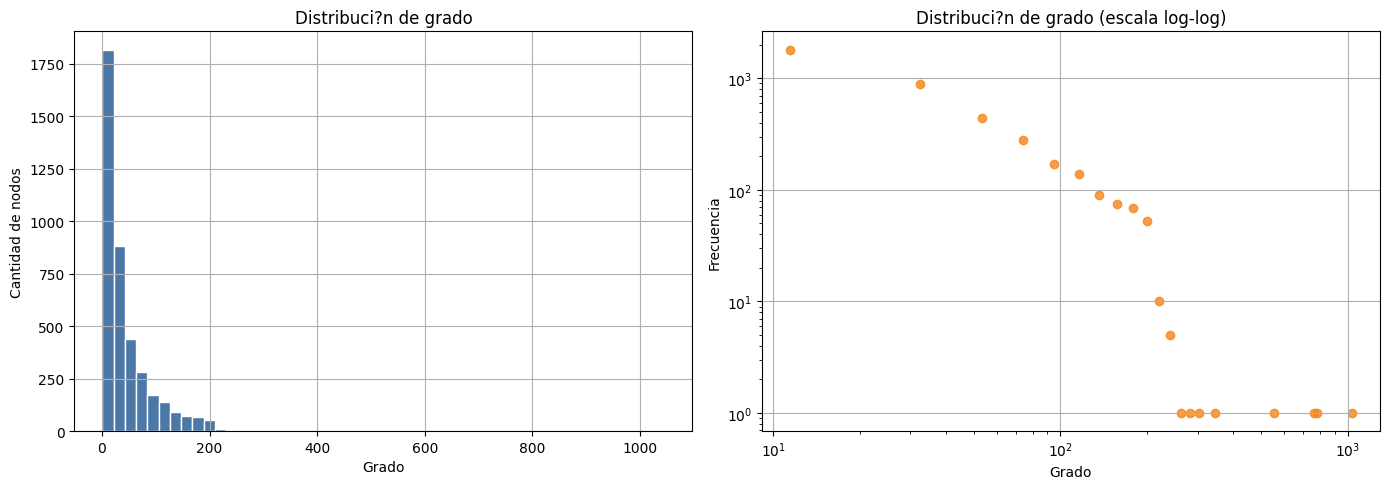

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degree_values, bins=50, color="#4C78A8", edgecolor="white")
axes[0].set_title("Distribuci?n de grado")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Cantidad de nodos")

hist, bin_edges = np.histogram(degree_values, bins=50)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mask = hist > 0
axes[1].scatter(centers[mask], hist[mask], color="#F58518", alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Distribuci?n de grado (escala log-log)")
axes[1].set_xlabel("Grado")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

La distribuci?n de grado permite identificar si la red es homog?nea o si hay perfiles con un n?mero de conexiones muy superior al promedio. En una red social es esperable observar heterogeneidad: muchos usuarios tienen grados moderados y unos pocos concentran gran cantidad de amistades.

**CENTRALIDADES**

In [12]:
degree_centrality = nx.degree_centrality(G_clean)
pagerank = nx.pagerank(G_clean, alpha=0.85)

# La intermediaci?n exacta puede tardar; para mantener el notebook ?gil usamos una aproximaci?n.
betweenness = nx.betweenness_centrality(G_clean, k=500, seed=42, normalized=True)

centrality_df = pd.DataFrame({
    "node": list(G_clean.nodes()),
    "degree": [degrees[n] for n in G_clean.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G_clean.nodes()],
    "pagerank": [pagerank[n] for n in G_clean.nodes()],
    "betweenness_aprox": [betweenness[n] for n in G_clean.nodes()],
})

centrality_df.sort_values("pagerank", ascending=False).head(10)

,node,degree,degree_centrality,pagerank,betweenness_aprox
1821,3437,547,0.135463,0.007615,0.222233
107,107,1045,0.258791,0.006936,0.489707
351,1684,792,0.196137,0.006367,0.344536
0,0,347,0.085934,0.006290,0.161446
352,1912,755,0.186974,0.003877,0.216324
348,348,229,0.056711,0.002348,0.035996
1831,686,170,0.042100,0.002219,0.035249
1827,3980,59,0.014611,0.002170,0.027921
349,414,159,0.039376,0.001800,0.043358
1843,698,68,0.016840,0.001317,0.113607


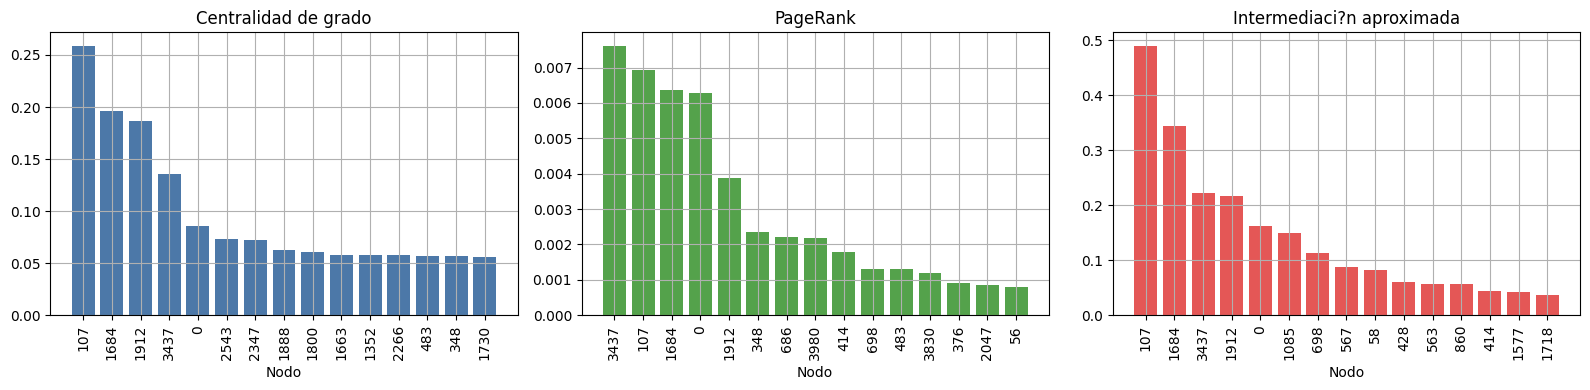

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ["degree_centrality", "pagerank", "betweenness_aprox"],
    ["Centralidad de grado", "PageRank", "Intermediaci?n aproximada"],
    ["#4C78A8", "#54A24B", "#E45756"]
):
    top = centrality_df.sort_values(col, ascending=False).head(15)
    ax.bar(top["node"].astype(str), top[col], color=color)
    ax.set_title(title)
    ax.set_xlabel("Nodo")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

La centralidad de grado identifica perfiles con muchas amistades directas. PageRank permite detectar nodos importantes por estar conectados a otros nodos relevantes. La intermediaci?n aproxima qu? nodos funcionan como puentes entre zonas de la red, un rol especialmente importante para conectar comunidades distintas.

**VISUALIZACI?N DE LA RED**

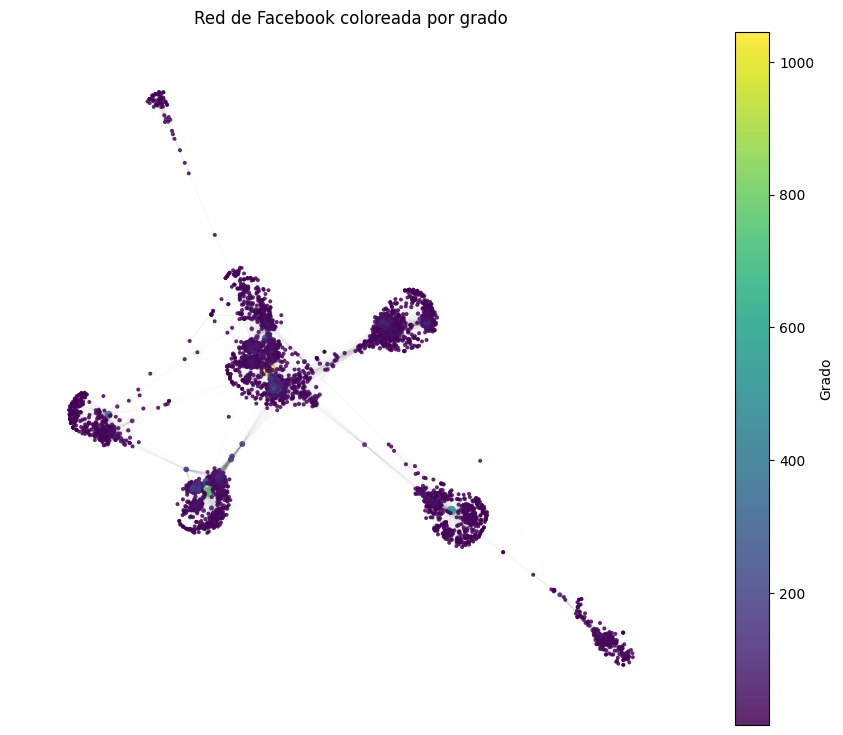

In [14]:
# Visualizaci?n completa usando posiciones precalculadas.
# Para mejorar la legibilidad, coloreamos por grado y escalamos suavemente el tama?o.
node_order = list(G_clean.nodes())
node_degrees = np.array([degrees[n] for n in node_order])
node_sizes = 8 + 70 * (node_degrees - node_degrees.min()) / (node_degrees.max() - node_degrees.min())

plt.figure(figsize=(11, 9))
nx.draw_networkx_edges(G_clean, pos, alpha=0.03, width=0.3, edge_color="gray")
nodes = nx.draw_networkx_nodes(
    G_clean,
    pos,
    nodelist=node_order,
    node_size=node_sizes,
    node_color=node_degrees,
    cmap="viridis",
    alpha=0.85,
    linewidths=0,
)
plt.colorbar(nodes, label="Grado")
plt.title("Red de Facebook coloreada por grado")
plt.axis("off")
plt.show()

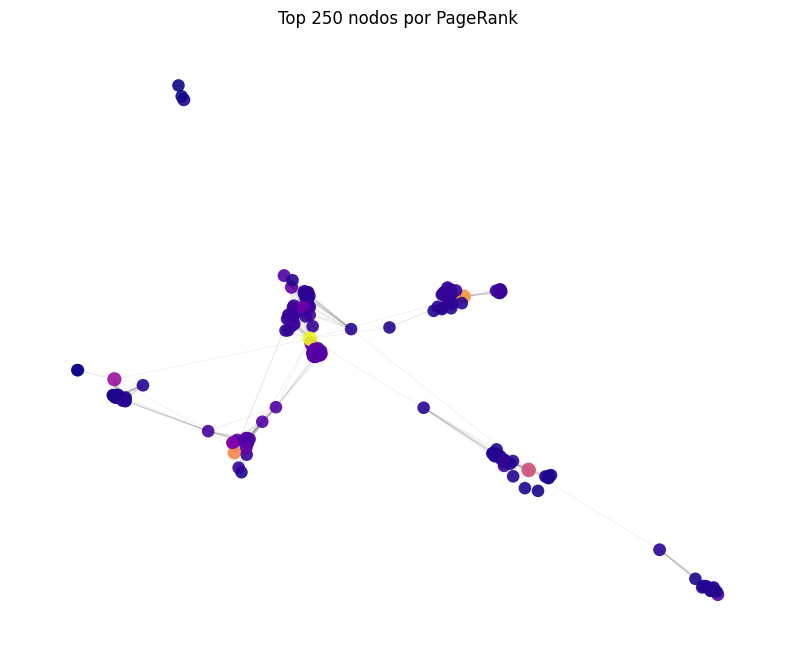

In [15]:
# Subgrafo de nodos m?s centrales por PageRank para una visualizaci?n m?s legible
top_nodes = centrality_df.sort_values("pagerank", ascending=False).head(250)["node"].tolist()
G_top = G_clean.subgraph(top_nodes).copy()
pos_top = {n: pos[n] for n in G_top.nodes() if n in pos}

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_top, pos_top, alpha=0.12, width=0.6, edge_color="gray")
nx.draw_networkx_nodes(
    G_top,
    pos_top,
    node_size=[80 + 4000 * pagerank[n] for n in G_top.nodes()],
    node_color=[degrees[n] for n in G_top.nodes()],
    cmap="plasma",
    alpha=0.9,
    linewidths=0,
)
plt.title("Top 250 nodos por PageRank")
plt.axis("off")
plt.show()

La visualizaci?n muestra una red con zonas densas y nodos m?s centrales que articulan partes relevantes del grafo. El archivo `fb_positions.pkl` permite observar la estructura topol?gica sin recalcular un layout costoso.

**DETECCI?N DE COMUNIDADES**

In [16]:
partition = cl.best_partition(G_clean, random_state=42)
modularity = cl.modularity(partition, G_clean)

communities_df = pd.DataFrame({
    "node": list(partition.keys()),
    "community": list(partition.values()),
    "degree": [degrees[n] for n in partition.keys()],
})

community_sizes = communities_df["community"].value_counts().sort_values(ascending=False)

print("Cantidad de comunidades:", community_sizes.shape[0])
print("Modularidad:", modularity)
community_sizes.head(15).to_frame("cantidad_nodos")

Cantidad de comunidades: 15
Modularidad: 0.8348824648429318


,cantidad_nodos
community,
10,548
2,535
4,442
9,432
1,430
0,354
6,323
12,237
8,226


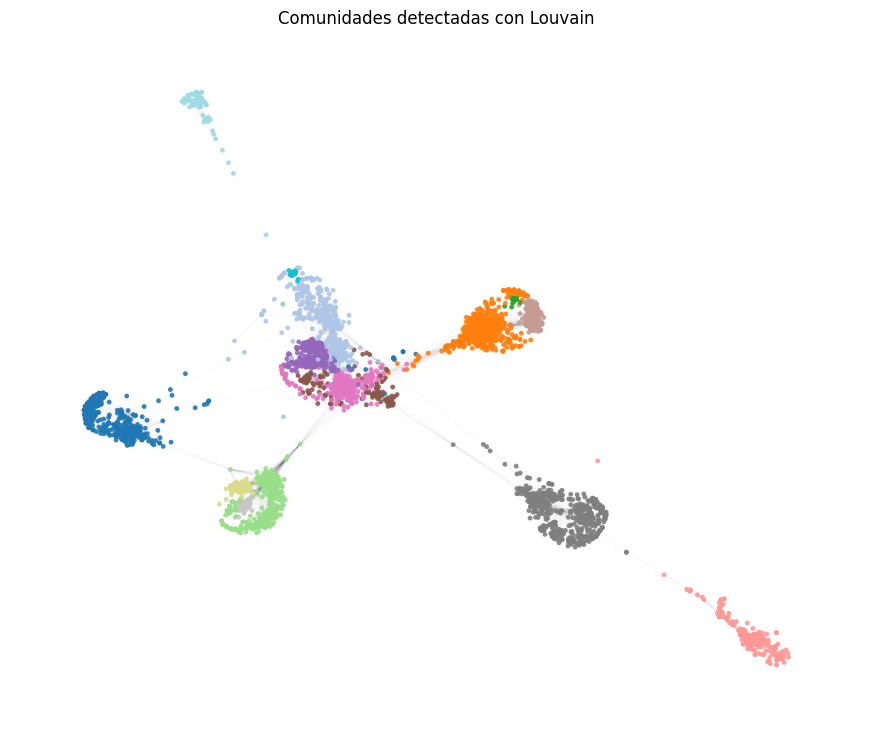

In [17]:
plt.figure(figsize=(11, 9))
colors = [partition[n] for n in G_clean.nodes()]

nx.draw_networkx_edges(G_clean, pos, alpha=0.025, width=0.25, edge_color="gray")
nx.draw_networkx_nodes(
    G_clean,
    pos,
    node_size=12,
    node_color=colors,
    cmap="tab20",
    alpha=0.9,
    linewidths=0,
)
plt.title("Comunidades detectadas con Louvain")
plt.axis("off")
plt.show()

Las comunidades detectadas por Louvain agrupan nodos que tienen m?s conexiones internas que externas. En el contexto de Facebook, estas comunidades pueden interpretarse como c?rculos sociales, grupos de pertenencia o zonas de afinidad dentro de la red.

**ROBUSTEZ DE LA RED**

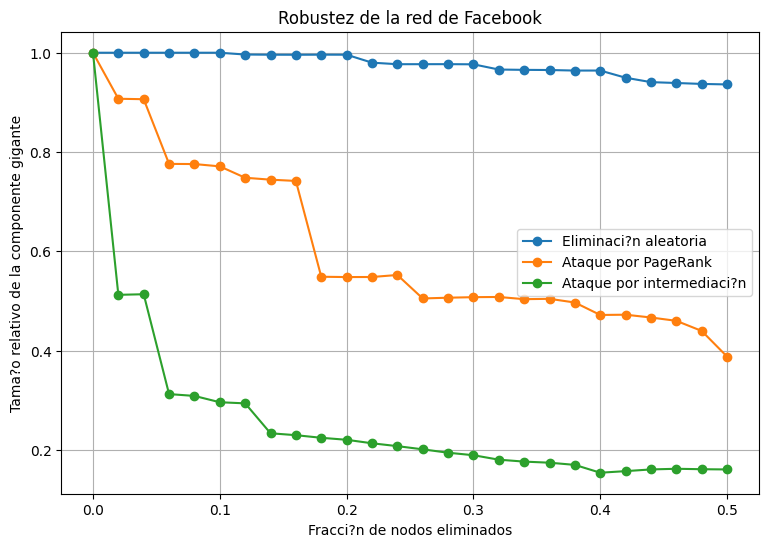

In [18]:
def giant_component_fraction(H):
    if H.number_of_nodes() == 0:
        return 0
    largest = max(nx.connected_components(H), key=len)
    return len(largest) / H.number_of_nodes()

nodes = list(G_clean.nodes())
random_order = nodes.copy()
np.random.shuffle(random_order)

pagerank_order = sorted(pagerank, key=pagerank.get, reverse=True)
betweenness_order = sorted(betweenness, key=betweenness.get, reverse=True)

def robustness_curve(G_base, removal_order, fractions=np.linspace(0, 0.5, 26)):
    results = []
    n = G_base.number_of_nodes()
    for frac in fractions:
        k = int(frac * n)
        H = G_base.copy()
        H.remove_nodes_from(removal_order[:k])
        results.append(giant_component_fraction(H))
    return fractions, results

fractions, curve_random = robustness_curve(G_clean, random_order)
_, curve_pagerank = robustness_curve(G_clean, pagerank_order)
_, curve_betweenness = robustness_curve(G_clean, betweenness_order)

plt.figure(figsize=(9, 6))
plt.plot(fractions, curve_random, marker="o", label="Eliminaci?n aleatoria")
plt.plot(fractions, curve_pagerank, marker="o", label="Ataque por PageRank")
plt.plot(fractions, curve_betweenness, marker="o", label="Ataque por intermediaci?n")
plt.xlabel("Fracci?n de nodos eliminados")
plt.ylabel("Tama?o relativo de la componente gigante")
plt.title("Robustez de la red de Facebook")
plt.legend()
plt.show()

La comparaci?n entre eliminaci?n aleatoria y ataques dirigidos permite evaluar la vulnerabilidad estructural de la red. Si la componente gigante cae m?s r?pido al remover nodos centrales, entonces esos perfiles cumplen un rol cr?tico en la conectividad global.

**COMPARACI?N CON RED ALEATORIA**

In [19]:
N = G_clean.number_of_nodes()
E = G_clean.number_of_edges()
p_er = (2 * E) / (N * (N - 1))

G_er = nx.erdos_renyi_graph(N, p_er, seed=42)
G_er_gc = G_er.subgraph(max(nx.connected_components(G_er), key=len)).copy()

def metricas_comparativas(H, H_gc):
    return {
        "nodos": H.number_of_nodes(),
        "aristas": H.number_of_edges(),
        "grado_promedio": np.mean([d for _, d in H.degree()]),
        "clustering_promedio": nx.average_clustering(H),
        "transitividad": nx.transitivity(H),
        "asortatividad": nx.degree_assortativity_coefficient(H),
        "distancia_media_gc": nx.average_shortest_path_length(H_gc),
        "diametro_gc": nx.diameter(H_gc),
    }

comparison = pd.DataFrame({
    "Facebook": metricas_comparativas(G_clean, G_gc),
    "Erdos-Renyi": metricas_comparativas(G_er, G_er_gc),
})

comparison

,Facebook,Erdos-Renyi
nodos,4039.000000,4039.000000
aristas,88234.000000,87553.000000
grado_promedio,43.691013,43.353800
clustering_promedio,0.605547,0.010766
transitividad,0.519174,0.010781
asortatividad,0.063577,0.003106
distancia_media_gc,3.692507,2.610505
diametro_gc,8.000000,4.000000


La red aleatoria de Erd?s-R?nyi conserva aproximadamente el mismo n?mero de nodos y enlaces esperados, pero no reproduce necesariamente la estructura social del grafo real. Si Facebook presenta mucho m?s clustering y una modularidad marcada, entonces no alcanza con explicar la red solo por densidad: hay organizaci?n local, c?rculos sociales y patrones de conexi?n no aleatorios.

**CONCLUSIONES**

El dataset de Facebook representa una red social no dirigida y no pesada, donde los nodos son perfiles y las aristas son relaciones de amistad. La red permite estudiar propiedades t?picas de sistemas sociales: alta cohesi?n local, existencia de comunidades y presencia de nodos con roles centrales.

A partir de las m?tricas globales, la distribuci?n de grado, las centralidades y la detecci?n de comunidades, se puede evaluar si la red presenta propiedades de mundo peque?o y si su estructura se aleja de una red aleatoria equivalente. La comparaci?n con Erd?s-R?nyi resulta especialmente ?til para mostrar que la red real no solo tiene muchos enlaces, sino que esos enlaces est?n organizados de manera socialmente significativa.

El an?lisis de robustez complementa esta lectura: una red social puede ser relativamente resistente a p?rdidas aleatorias de nodos, pero m?s vulnerable cuando se remueven usuarios centrales o usuarios puente entre comunidades.